In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [18]:

# Load dataset
df = pd.read_csv('../data/processed/cleaned_supply_chain_data.csv')

print("--- Dataset Info ---")
print(df.info())
print("\n--- Head ---")
print(df.head())

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   str    
 1   Date                       5000 non-null   str    
 2   Origin_Port                5000 non-null   str    
 3   Destination_Port           5000 non-null   str    
 4   Transport_Mode             5000 non-null   str    
 5   Product_Category           5000 non-null   str    
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   str    
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-nu

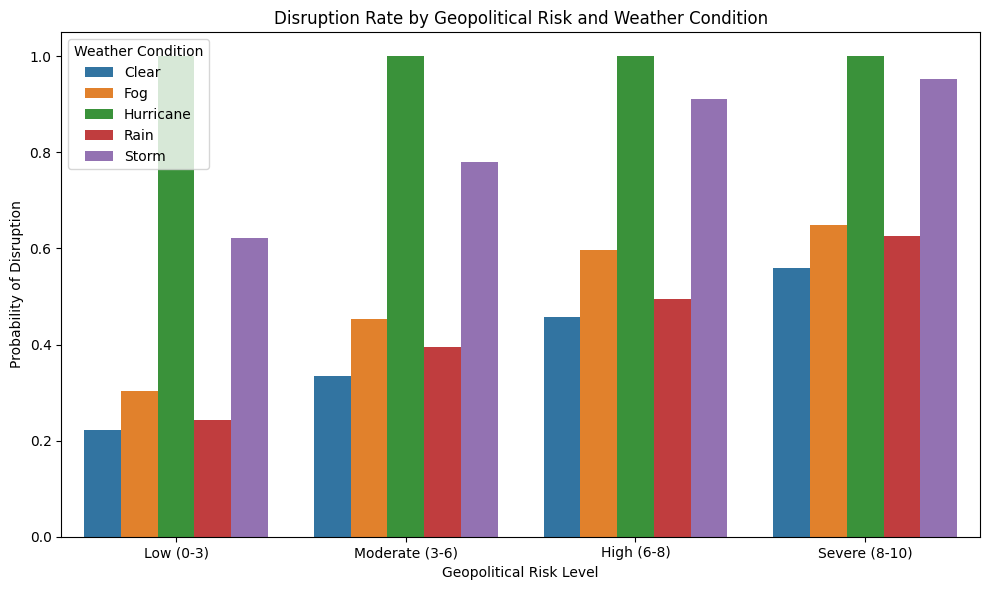

In [19]:

# 1. Tipping Point Analysis
# Bin Geopolitical_Risk_Score
df['Geo_Risk_Bin'] = pd.cut(df['Geopolitical_Risk_Score'], bins=[0, 3, 6, 8, 10], labels=['Low (0-3)', 'Moderate (3-6)', 'High (6-8)', 'Severe (8-10)'])

# Calculate disruption rates for Weather x Geo Risk
tipping_point = df.groupby(['Geo_Risk_Bin', 'Weather_Condition'])['Disruption_Occurred'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=tipping_point, x='Geo_Risk_Bin', y='Disruption_Occurred', hue='Weather_Condition')
plt.title('Disruption Rate by Geopolitical Risk and Weather Condition')
plt.ylabel('Probability of Disruption')
plt.xlabel('Geopolitical Risk Level')
plt.legend(title='Weather Condition')
plt.tight_layout()
plt.savefig('tipping_point.png')
plt.show()
plt.close()

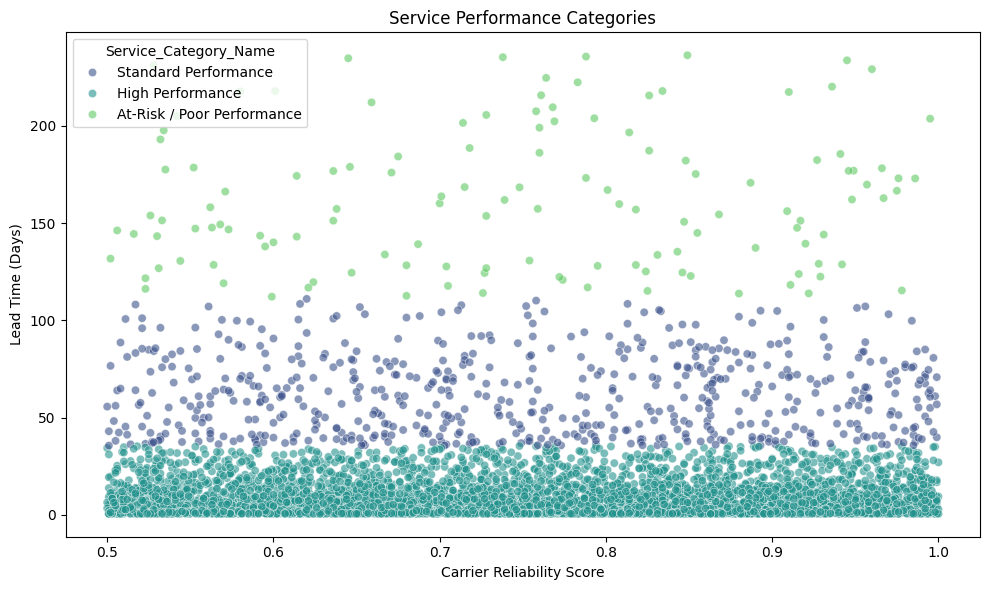

In [20]:

# 2. Service Performance Categories (Clustering)
# Features: Carrier_Reliability_Score, Lead_Time_Days
X_cluster = df[['Carrier_Reliability_Score', 'Lead_Time_Days']].dropna()
kmeans = KMeans(n_clusters=3, random_state=42)
df['Performance_Category'] = kmeans.fit_predict(X_cluster)

# Map clusters to meaningful names based on means
cluster_means = df.groupby('Performance_Category')[['Carrier_Reliability_Score', 'Lead_Time_Days']].mean().sort_values('Lead_Time_Days')
# e.g., shortest lead time = 'High Performance', middle = 'Standard', longest = 'At Risk'
labels = ['High Performance', 'Standard Performance', 'At-Risk / Poor Performance']
cluster_mapping = {idx: label for idx, label in zip(cluster_means.index, labels)}
df['Service_Category_Name'] = df['Performance_Category'].map(cluster_mapping)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Carrier_Reliability_Score', y='Lead_Time_Days', hue='Service_Category_Name', palette='viridis', alpha=0.6)
plt.title('Service Performance Categories')
plt.xlabel('Carrier Reliability Score')
plt.ylabel('Lead Time (Days)')
plt.tight_layout()
plt.savefig('service_categories.png')
plt.show()
plt.close()

In [ ]:

# 3. Forecasting Model (Predicting Disruption_Occurred)
# Prepare data
features = ['Transport_Mode', 'Product_Category', 'Distance_km', 'Weight_MT',
            'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Weather_Condition',
            'Carrier_Reliability_Score', 'Lead_Time_Days', 'Origin_port', 'Destination_port']
X = df[features]
y = df['Disruption_Occurred']

# Encode categorical
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("\n--- Model Evaluation (Disruption_Occurred) ---")
print(classification_report(y_test, y_pred, target_names=['No Disruption', 'Disruption Occurred']))

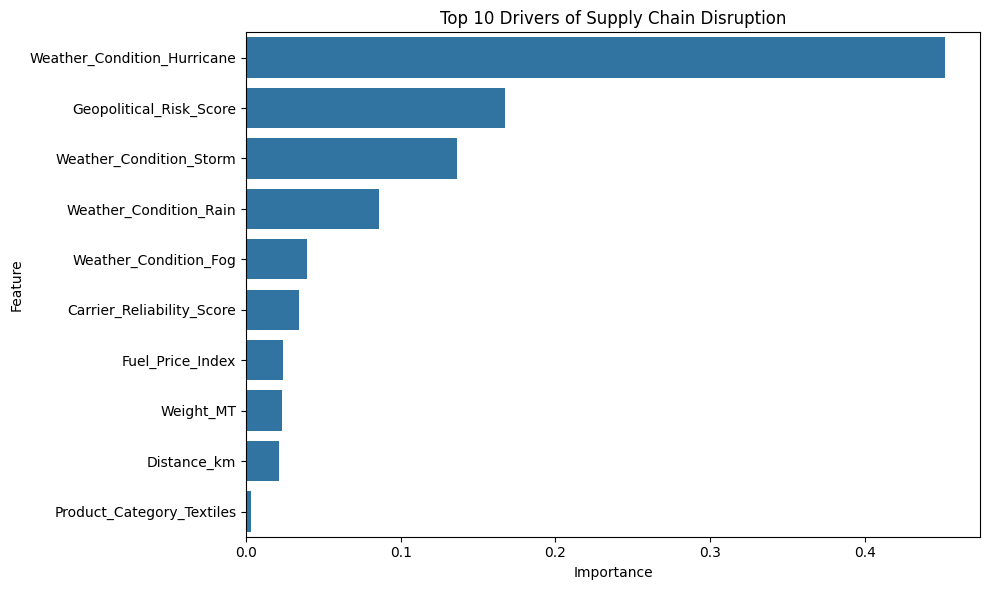

                        Feature  Importance
13  Weather_Condition_Hurricane    0.451998
3       Geopolitical_Risk_Score    0.167353
15      Weather_Condition_Storm    0.136272
14       Weather_Condition_Rain    0.085776
12        Weather_Condition_Fog    0.039656
4     Carrier_Reliability_Score    0.034117
2              Fuel_Price_Index    0.023827
1                     Weight_MT    0.023430
0                   Distance_km    0.021426
11    Product_Category_Textiles    0.003499


In [22]:

# Feature Importance
importances = clf.feature_importances_
feature_names = X_encoded.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 Drivers of Supply Chain Disruption')
plt.tight_layout()
plt.show()
plt.savefig('feature_importance.png')
plt.close()

print(feature_importance_df.head(10))